Load & Combine Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")

df = pd.concat([ethiopia, kenya, nigeria, sudan, tanzania])

Temperature Trend Comparison

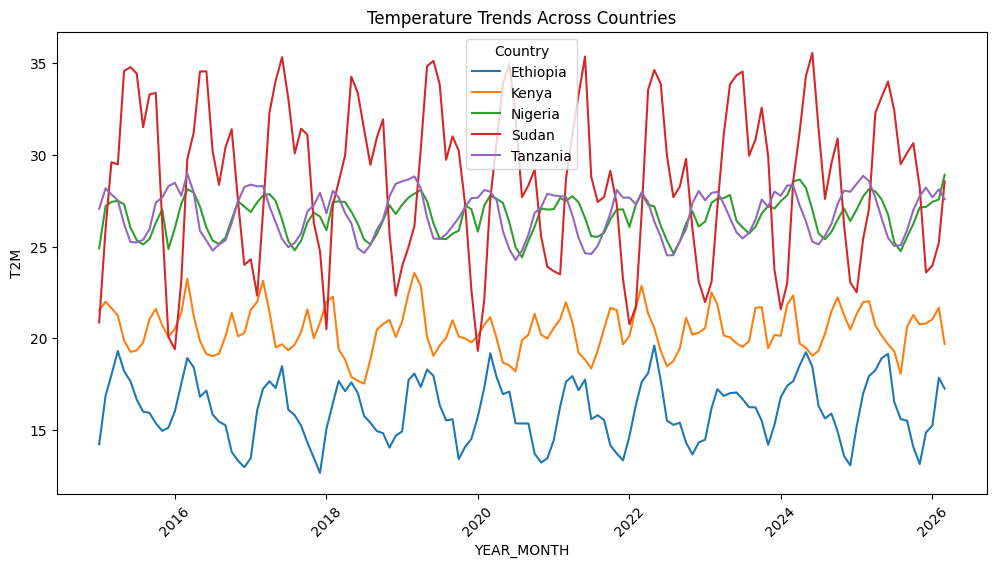

In [7]:
df["YEAR_MONTH"] = pd.to_datetime(df["DATE"]).dt.to_period("M").dt.to_timestamp()

monthly_temp = df.groupby(["YEAR_MONTH", "Country"])["T2M"].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_temp, x="YEAR_MONTH", y="T2M", hue="Country")
plt.xticks(rotation=45)
plt.title("Temperature Trends Across Countries")
plt.show()

In [8]:
temp_summary = df.groupby("Country")["T2M"].agg(["mean", "median", "std"])
temp_summary

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


Precipitation Variability Comparison

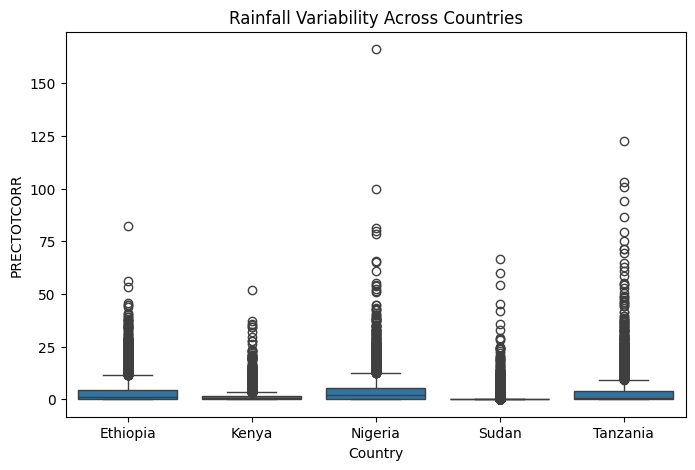

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Country", y="PRECTOTCORR")
plt.title("Rainfall Variability Across Countries")
plt.show()

In [10]:
rain_summary = df.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"])
rain_summary

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


Extreme Events-Extreme Heat Days (>35°C)

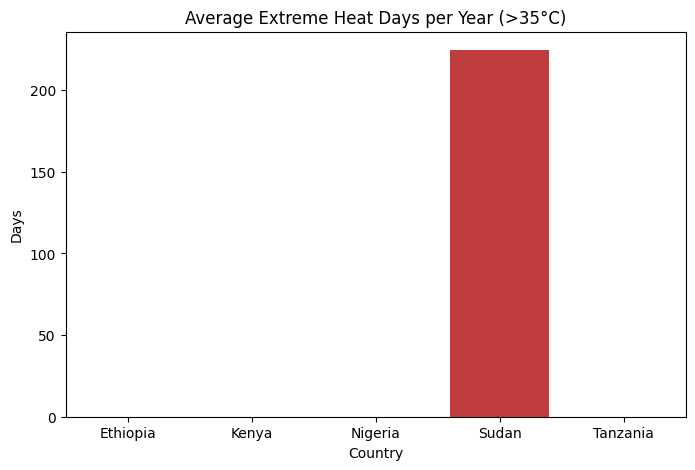

In [24]:
extreme_heat = df[df["T2M_MAX"] > 35] \
    .groupby(["Country", "YEAR"]) \
    .size() \
    .reset_index(name="Extreme_Heat_Days")
all_countries = df["Country"].unique()

extreme_heat_avg = extreme_heat.groupby("Country")["Extreme_Heat_Days"].mean()

# reindex to include all countries
extreme_heat_avg = extreme_heat_avg.reindex(all_countries, fill_value=0).reset_index()
plt.figure(figsize=(8,5))
sns.barplot(data=extreme_heat_avg, x="Country", y="Extreme_Heat_Days", hue="Country", legend=False)

plt.title("Average Extreme Heat Days per Year (>35°C)")
plt.ylabel("Days")
plt.show()

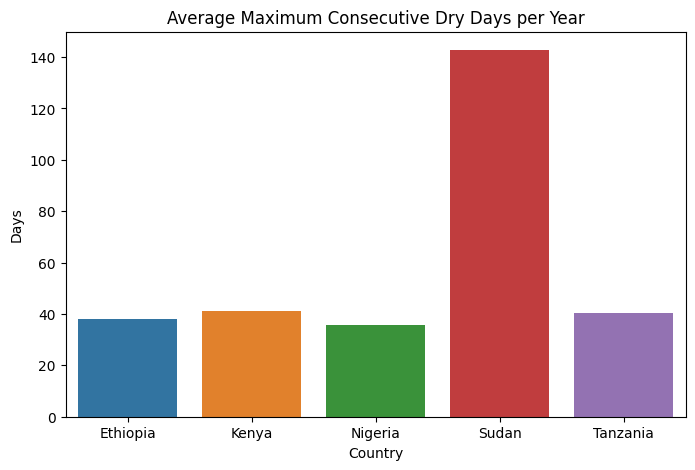

In [25]:
df = df.sort_values(["Country", "DATE"])

df["is_dry"] = df["PRECTOTCORR"] < 1
df["dry_group"] = (df["is_dry"] != df["is_dry"].shift()).cumsum()

dry_streaks = df[df["is_dry"]] \
    .groupby(["Country", "YEAR", "dry_group"]) \
    .size() \
    .reset_index(name="streak_length")

max_dry_streak = dry_streaks.groupby(["Country", "YEAR"])["streak_length"].max().reset_index()
dry_avg = max_dry_streak.groupby("Country")["streak_length"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=dry_avg, x="Country", y="streak_length", hue="Country", legend=False)

plt.title("Average Maximum Consecutive Dry Days per Year")
plt.ylabel("Days")
plt.show()

Statistical Testing

In [26]:
from scipy.stats import f_oneway

groups = [group["T2M"].values for name, group in df.groupby("Country")]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 18938.7456970699
p-value: 0.0


A one-way ANOVA test was conducted to compare temperature (T2M) across these five countries. The resulting p value is less than 0.05, which shows that the temperature difference between these five countries is statistically significant.

Therefore, variations in temperature is less likely due to random chance, instead shows that each country has its own temperature characterstics

In [27]:
ranking = pd.DataFrame({
    "Country": temp_summary.index,
    "Avg_Temperature": temp_summary["mean"],
    "Rainfall_Variability": rain_summary["std"],
    "Extreme_Heat_Days": extreme_heat_avg.set_index("Country")["Extreme_Heat_Days"],
    "Max_Dry_Streak": dry_avg.set_index("Country")["streak_length"]
}).reset_index(drop=True)

ranking

ranking = ranking.sort_values(
    by=["Extreme_Heat_Days", "Max_Dry_Streak"],
    ascending=False
)

ranking

,Country,Avg_Temperature,Rainfall_Variability,Extreme_Heat_Days,Max_Dry_Streak
3,Sudan,28.759007,3.057672,224.5,142.750000
1,Kenya,20.427600,3.180228,0.0,41.083333
4,Tanzania,26.802422,8.003947,0.0,40.250000
0,Ethiopia,16.068500,6.289061,0.0,37.916667
2,Nigeria,26.656928,7.266742,0.0,35.833333


- Sudan is most exposed due to the high average temperature and the frequency of heatwaves and prolonged dry spells. Also, there are implications for the faster warming of Sudan among the analyzed countries as climate stress and temperature levels are increasing.

- Variability of rainfall occurs highly in Nigeria and Tanzania where climate stability can be negatively impacted since it is prone to flooding and droughts in both countries. Therefore, the precipitation patterns in Nigeria and Tanzania are unstable.

- According to research on the occurrence of extreme events, Sudan is the most exposed to heat extremes as well as prolonged dry spells, while the rest of the countries are exposed to moderate seasonal dry spells and heat exposure. Thus, Sudan is under the highest climate stress in comparison to others.

- Ethiopia can be characterized by the most climate stability and low average temperatures and moderate variability as well. In comparison to neighboring countries, it is least exposed to extreme climatic events, although it is exposed to drought seasonally.

- Considering the findings, Sudan should receive priority concerning climate funding during COP32 since this country has the highest exposure to heat and drought extremes, thus prolonged drought conditions, making it the most vulnerable country in this analysis.